In [23]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [26]:
df = pd.read_csv("boston_housing.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [27]:
x = df.drop(columns=['MEDV'])
y = df['MEDV']

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)


In [28]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [29]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(x_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1),
])
model.compile(loss='mse', optimizer=Adam(learning_rate=0.001), metrics=['mae'])
model.summary()

C:\Users\DELL\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=200, batch_size=32, callbacks=early_stopping)

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 625.0780 - mae: 23.1996 - val_loss: 514.7365 - val_mae: 21.0365
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 555.5446 - mae: 21.6779 - val_loss: 477.4508 - val_mae: 20.1504
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 528.2604 - mae: 21.1906 - val_loss: 435.5390 - val_mae: 19.1268
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 484.3551 - mae: 19.9152 - val_loss: 383.9924 - val_mae: 17.8133
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 480.5428 - mae: 19.7159 - val_loss: 318.9114 - val_mae: 16.0585
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 345.3353 - mae: 16.3927 - val_loss: 244.4349 - val_mae: 13.8546
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 253.0248 - mae: 13.9522 - val_loss: 166.8680 - val_mae: 11.1576
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 194.2077 - mae: 11.2220 - val_loss: 104.5872 - val_mae: 8.6095
Epoch 9/200
1

In [31]:
model.evaluate(x_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 8.0793 - mae: 1.9815


[9.54698657989502, 2.065073251724243]

In [32]:
from sklearn.metrics import r2_score, mean_squared_error
y_pred = model.predict(x_test)
print(f"r2_score {r2_score(y_test, y_pred)}")
print(f"mse {mean_squared_error(y_test, y_pred)}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
r2_score 0.8698146210348595
mse 9.546986351674084


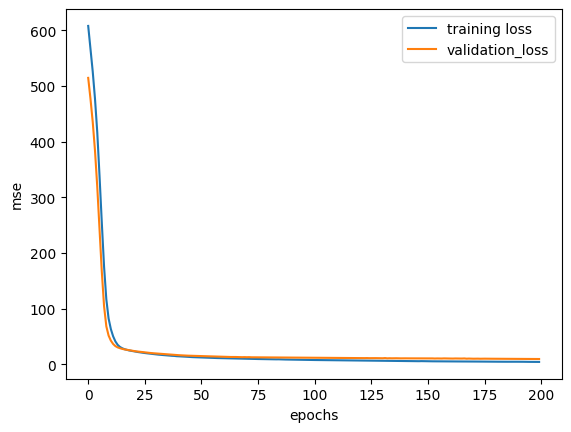

In [33]:
plt.plot(history.history['loss'], label='training loss')
plt.plot(history.history['val_loss'], label='validation_loss')
plt.xlabel('epochs')
plt.ylabel('mse')
plt.legend()
plt.show()